# Fig5_nichespace_clustering.ipynb

This notebook demonstrates clustering of species niche spaces, drawing dendrograms, visualizing average niche spaces, and performing related calculations and plots.

In [1]:
from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail
import yaml
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.decomposition import PCA
import math
import feather
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, set_link_color_palette
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib as mpl
from scipy.stats import skewnorm
import matplotlib.ticker as mtick
from matplotlib.ticker import ScalarFormatter

# Set default matplotlib parameters.
set_mpl_defaults()

### Translate species name to Chinese

In [2]:
def get_chinese_sciname(target_name):
    change_names = {
    'Anas_zonorhyncha': 'Anas_poecilorhyncha', 
    'Cyanoderma_ruficeps': 'Stachyridopsis_ruficeps', 
    'Erythrogenys_erythrocnemis': 'Pomatorhinus_erythrocnemis', 
    'Ictinaetus_malaiensis': 'Ictinaetus_malayensis', 
    'Lewinia_striata': 'Gallirallus_striatus', 
    'Machlolophus_holsti': 'Parus_holsti', 
    'Pterorhinus_poecilorhynchus': 'Garrulax_poecilorhynchus', 
    'Pterorhinus_ruficeps': 'Garrulax_ruficeps', 
    'Schoeniparus_brunneus': 'Alcippe_brunnea', 
    'Sittiparus_castaneoventris': 'Poecile_varius', 
    'Synoicus_chinensis': 'Coturnix_chinensis', 
    'Taenioptynx_brodiei': 'Glaucidium_brodiei', 
    'Tarsiger_formosanus': 'Tarsiger_indicus', 
    'Turdus_niveiceps': 'Turdus_poliocephalus', 
    'Zapornia_fusca': 'Porzana_fusca'
    }
    df_name = pd.read_csv('../2023臺灣鳥類名錄-20230419.csv')
    for (new_name, orig_name) in change_names.items():
        if target_name == orig_name:
            target_name = new_name
            
    df_target = df_name[df_name['學名'] == target_name.replace('_', ' ')]
    return df_target['中文名'].values[0]

## Define run and experiment IDs
The PlotUtlis class uses these IDs to locate various data and configuration paths.

In [3]:
run_id = '144fa175d5d1428cb9b434cd1a0024f8'
exp_id = '625518819310735286'

## Initialize PlotUtlis
This instantiates the PlotUtlis object, which provides convenience methods for data loading, saving, and plotting.

In [4]:
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

## Create directory for niche space clustering plots
Ensures the target directory exists for saving our clustering figures.

In [5]:
create_folder(PU.plot_path_nichespace_clustering)

## Retrieve DeepSDM niche space data
Loads precomputed niche space arrays for each species from disk.

In [6]:
species_list_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
nichespace_deepsdm_all, nichespace_deepsdm_all_nonflatten = PU.get_deepsdm_nichespace(species_exclude = species_list_exclude, suffix = 'max')

## Hierarchical clustering
Perform hierarchical clustering on the flattened niche space data.

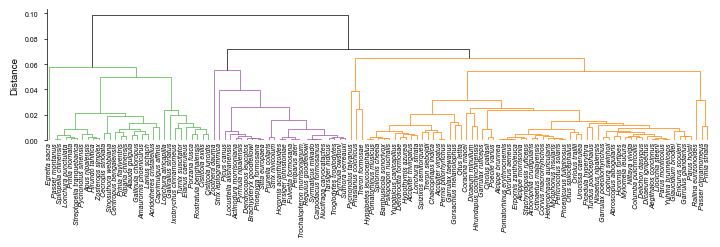

In [7]:
# Define the optimal number of clusters.
k_optimal = 3

# Compute hierarchical linkage.
linked = linkage(nichespace_deepsdm_all, method='average', metric='cosine')

# Generate cluster labels.
cluster_labels = fcluster(linked, t=k_optimal, criterion='maxclust')

# Determine distance threshold.
max_d = linked[-(k_optimal-1), 2]

# Plot the dendrogram.
fig, ax = plt.subplots(figsize=mm2inch(180, 60), constrained_layout = True)
set_link_color_palette(PU.color_list)
d_data = dendrogram(
    linked,
    orientation='top',
    distance_sort='ascending',
    show_leaf_counts=False,
    color_threshold=max_d,
    labels=[sp.replace('_', ' ') for sp in PU.species_list_predict if sp not in species_list_exclude],
    # labels=[sp.replace('_', ' ') for sp in PU.species_list_predict],     # Use this line if no species_list_exclude
    above_threshold_color = 'black',
    ax = ax
)

# Adjust x-axis tick labels (species names), font size, italic style.
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 5, fontstyle='italic', rotation=90, ha='center', va = 'top')
ax.set_ylabel('Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set consistent line width on the dendrogram lines.
for line_collection in ax.collections:
    line_collection.set_linewidth(0.5)

# Adjust tick label spacing.
ax.tick_params(axis='x', which='major', pad=-1)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'nichespace_clustering_dendrogram.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

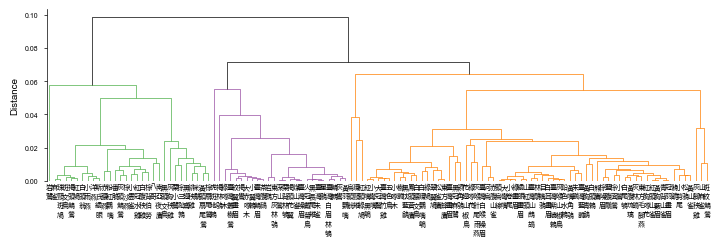

In [8]:
from matplotlib import font_manager as fm

# 設置字體為 Noto Sans CJK
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'  # 檢查該路徑是否存在
font_prop = fm.FontProperties(fname=font_path)

# Define the optimal number of clusters.
k_optimal = 3

# Compute hierarchical linkage.
linked = linkage(nichespace_deepsdm_all, method='average', metric='cosine')

# Generate cluster labels.
cluster_labels = fcluster(linked, t=k_optimal, criterion='maxclust')

# Determine distance threshold.
max_d = linked[-(k_optimal-1), 2]

# Plot the dendrogram.
fig, ax = plt.subplots(figsize=mm2inch(180, 60), constrained_layout = True)
set_link_color_palette(PU.color_list)
d_data = dendrogram(
    linked,
    orientation='top',
    distance_sort='ascending',
    show_leaf_counts=False,
    color_threshold=max_d,
    labels=[get_chinese_sciname(sp) for sp in PU.species_list_predict if sp not in species_list_exclude],
    above_threshold_color = 'black',
    ax = ax
)

# Adjust x-axis tick labels (species names), font size, italic style.
ls = [l.get_text() for l in ax.get_xticklabels()]
vls = ['\n'.join(list(l)) for l in ls]
ax.set_xticklabels(vls, fontsize = 4, ha='center', va = 'top', fontproperties = font_prop, rotation = 0)
ax.set_ylabel('Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set consistent line width on the dendrogram lines.
for line_collection in ax.collections:
    line_collection.set_linewidth(0.5)

# Adjust tick label spacing.
ax.tick_params(axis='x', which='major', pad=-1)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'nichespace_clustering_dendrogram_chinese.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

## Generate cluster-level average niches
The following code computes the average niche map for each identified cluster.

In [9]:
all_cluster_avg_niches = PU.get_all_cluster_average_nichespace(cluster_labels, nichespace_deepsdm_all_nonflatten)
img_sign = np.sign(all_cluster_avg_niches[0][1])

## Write cluster labels and average niche space data
Stores the computed labels and averages to YAML files for subsequent usage.

In [10]:
with open(PU.cluster_labels_path, 'w') as f:
    yaml.dump(cluster_labels.tolist(), f)
    
all_cluster_avg_niches_converted = {int(i):j.tolist() for i, j in all_cluster_avg_niches}
with open(PU.cluster_avg_nichespace_path, 'w') as f:
    yaml.dump(all_cluster_avg_niches_converted, f)

## Visualization of average niche space per cluster
Here, each cluster's mean niche space is saved as an image.

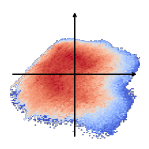

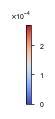

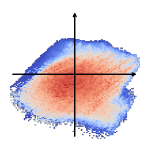

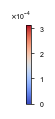

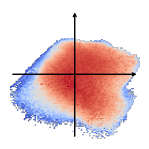

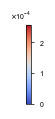

In [11]:
for (i_img, img) in all_cluster_avg_niches:
    fig, ax = plt.subplots(figsize = mm2inch(35, 35), constrained_layout = True)
    img_nan = np.where(img <= 0, np.nan, img)
    ax.imshow(img_nan, vmin = 0, cmap = 'coolwarm', extent = PU.nichespace_extent)
    ax.axis('off')

    # X-axis arrow.
    ax.annotate(
        '',
        xy=(6, 0),
        xytext=(-6, 0),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )

    # Y-axis arrow.
    ax.annotate(
        '',
        xy=(0, 6),
        xytext=(0, -6),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    plot_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_avg_cluster{i_img}.pdf')
    plt.savefig(plot_output, transparent = True, dpi = 500)
    plt.show()

    # Plot a separate colorbar for each cluster.
    fig_cb, ax_cb = plt.subplots(figsize = mm2inch(10, 25), gridspec_kw = {'left': 0.38, 'right': 0.5, 'bottom': 0.05, 'top': 0.85})
    norm = plt.Normalize(vmin = 0, vmax = np.nanmax(img_nan))
    cb = fig_cb.colorbar(plt.cm.ScalarMappable(norm = norm, cmap='coolwarm'), cax = ax_cb, orientation = 'vertical')

    formatter = mtick.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax_cb.yaxis.set_major_formatter(formatter)

    cb_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_avg_cluster{i_img}_colorbar.pdf')
    plt.savefig(cb_output, transparent=True, dpi=500)
    plt.show()

## Visualization of average niche space per cluster
Here, each cluster's mean niche space is saved as an image.

In [12]:
df_center = PU.calculate_deepsdm_nichespace_center(nichespace_deepsdm_all_nonflatten, cluster_labels)
df_center.to_csv(PU.df_nichespace_center_coordinate_path)
df_center

,PC01,PC02,cluster
Abroscopus_albogularis,0.776390,-0.778880,3
Accipiter_trivirgatus,0.568515,-0.691717,3
Accipiter_virgatus,0.646715,-0.656749,3
Acridotheres_cristatellus,-0.223778,-0.667487,1
Actinodura_morrisoniana,0.421784,-1.126376,2
...,...,...,...
Urocissa_caerulea,0.862855,-0.820650,3
Yuhina_brunneiceps,0.896700,-0.981503,3
Yungipicus_canicapillus,0.476620,-0.679137,3
Zoothera_dauma,0.623258,-0.930123,2


## Compute LDA of clustered niche centers

In [13]:
df_lda_result, df_ldaonPC, lda_explained_ratio, k_fold_validation = PU.calculate_nichecenter_cluster_lda()
df_lda_result

Stratified 5-fold CV accuracy: 0.925 (± 0.049)


,variable,importance_pc,loading_PC1,loading_PC2,proj_on_LD1,proj_on_LD2
0,tas,0.185427,0.024169,0.805828,0.517634,0.804448
1,EVI,0.182198,0.503656,0.436102,0.665506,0.417807
2,rsds,0.179846,-0.124006,0.880125,0.447210,0.883997
3,pr,0.157507,0.659089,0.219039,0.653287,0.195324
4,clt,0.105231,0.834228,-0.217276,0.520875,-0.246977
5,sfcWind,0.093294,-0.371025,-0.302449,-0.478614,-0.288985
6,hurs,0.089739,0.784748,-0.227632,0.475597,-0.255557
7,landcover_PC01,0.006586,0.233094,-0.114568,0.112211,-0.122833
8,landcover_PC02,0.000115,0.022847,-0.000007,0.017943,-0.000824
9,landcover_PC04,0.000051,0.013364,0.002243,0.011886,0.001764


In [31]:
df_ldaonPC.LD1.PC02 / df_ldaonPC.LD1.PC01

0.7877322010880757

## Overlap visualization of average clusters in niche space
Combines the top 50% density areas of each cluster's average niche, plus PCA loadings vectors.

In [14]:
unique_labels, label_to_color = PU.align_label_to_color(k_optimal, cluster_labels)

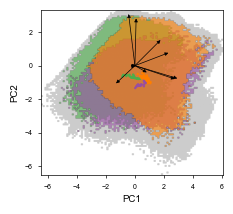

In [15]:
fig, ax = plt.subplots(figsize=mm2inch(55, 50), 
                       gridspec_kw = {'left': 0.15, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Display the background mask (significant region) in grey with transparency
ax.imshow(np.where(img_sign == 1, img_sign, np.nan),
          alpha=0.4,
          extent=PU.nichespace_extent,
          cmap=ListedColormap('grey'))
ax.set_aspect('auto')

# Overlay each cluster’s average niche region
for i_cluster, lbl in enumerate(unique_labels):
    # Get average niche map for the current cluster
    cluster_i_avg_niche = np.where(all_cluster_avg_niches[i_cluster][1] > 0,
                                   all_cluster_avg_niches[i_cluster][1],
                                   np.nan)
    # Define the threshold (50th percentile of non-NaN values)
    cluster_i_threshold = np.nanpercentile(cluster_i_avg_niche, 50)
    
    # Create a single-color colormap for this cluster
    single_cmap = ListedColormap([label_to_color[int(lbl)]]).copy()
    single_cmap.set_bad(alpha=0)
    
    # Display the thresholded cluster region
    ax.imshow(np.where(cluster_i_avg_niche >= cluster_i_threshold, 1, np.nan),
              extent=PU.nichespace_extent,
              cmap=single_cmap,
              alpha=0.6)
    ax.set_aspect('auto')

# Draw environmental variable vectors from the origin
for env in PU.env_list:
    dx = PU.env_pca_loadings.loc[env][f'PC{PU.x_pca:02d}'] * 3.5
    dy = PU.env_pca_loadings.loc[env][f'PC{PU.y_pca:02d}'] * 3.5
    ax.annotate(
        '',                              # No text, just an arrow
        xy=(dx, dy),                     # Arrow tip (end)
        xytext=(0, 0),                   # Arrow base (start)
        arrowprops=dict(
            arrowstyle='-|>',            # Arrowhead style
            lw=0.5,                      # Line width
            mutation_scale=5,            # Scale factor for arrowhead size (pt)
            fc='black',                  # Fill color (black)
            shrinkA=0,
            shrinkB=0
        )
    )

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Scatter plot of species niche centroids, colored by cluster label
point_colors = [label_to_color[int(lbl)] for lbl in cluster_labels]
ax.scatter(x=df_center['PC01'],
           y=df_center['PC02'],
           c=point_colors,
           s=0.5)

# Save figure as a transparent high-resolution PDF
plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'cluster_mean_env.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)

# Display the final figure
plt.show()

## Plot species niche centroids and the largest variance direction
Scatter plot of species-level PC1 vs PC2 plus a dashed line representing direction of maximum variance.

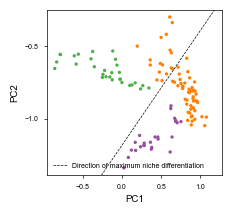

In [27]:
fig, ax = plt.subplots(figsize=mm2inch(55, 50), 
                       gridspec_kw = {'left': 0.18, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Scatter plot of species niche centroids in environmental PCA space
ax.scatter(x=df_center['PC01'],
           y=df_center['PC02'],
           c=point_colors,
           s=2)

# Calculate the centroid of all points (used to center the line of maximum variation)
center_x = df_center["PC01"].mean()
center_y = df_center["PC02"].mean()

# Compute and plot the line representing the direction of maximum variation among species niche centroids
# Equation: y = slope * (x - center_x) + center_y
x_vals_shifted = np.linspace(df_center["PC01"].min(), df_center["PC01"].max()+0.1, 100)
y_vals_shifted = df_ldaonPC.LD1.PC02 / df_ldaonPC.LD1.PC01 * (x_vals_shifted - center_x) + center_y

ax.plot(x_vals_shifted, y_vals_shifted,
        color="black",
        linestyle="--",
        linewidth=0.5,
        label="Direction of maximum niche differentiation")

# Add legend
ax.legend(loc='lower left', frameon=False)

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Define tick positions for both axes
ax.set_xticks([-0.5, 0, 0.5, 1])
ax.set_yticks([-1.0, -0.5])

# Set y-axis range slightly beyond data limits for better spacing
ax.set_ylim([df_center["PC02"].min() - 0.05,
             df_center["PC02"].max() + 0.05])

# Save figure as a transparent high-resolution PDF
plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'niche_center_LDAaxis1.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)

# Display plot
plt.show()


## Plot importance of environmental factors of LDA
Displays the importance of each environmental factor to LDA result.

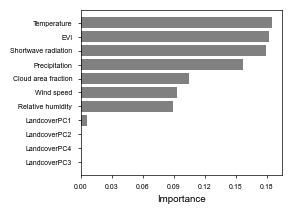

In [17]:
fig, ax = plt.subplots(figsize=mm2inch(70, 50), 
                       gridspec_kw = {'left': 0.26, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Get y-axis labels (according to the mapping in env_list_change dictionary)
y_labels = convert_to_env_list_detail(df_lda_result.variable)

# Plot each bar
for i, (env, value) in enumerate(zip(df_lda_result.variable,
                                     df_lda_result.importance_pc)):
    ax.barh(y_labels[i], value, color="grey")

# Set x-axis label
ax.set_xlabel("Importance")

# Set custom x-axis ticks
ax.set_xticks([0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Invert y-axis to show the most correlated variable at the top
ax.invert_yaxis()

# Remove background grid lines
ax.grid(False)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'lda_importance.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)
plt.show()

## Environmental medians violin plots of species among three clusters

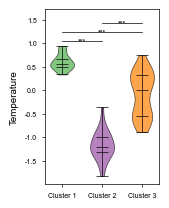

Overall Kruskal–Wallis (3 clusters): H=86.485, p=1.66e-19
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=40.179, p=2.32e-10
  Cluster 1 vs Cluster 3: H=47.837, p=4.63e-12
  Cluster 2 vs Cluster 3: H=49.211, p=2.3e-12
[Saved] Updated results for 'tas' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


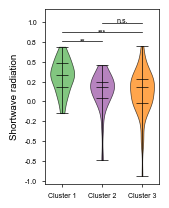

Overall Kruskal–Wallis (3 clusters): H=13.329, p=0.00128
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=8.650, p=0.00327
  Cluster 1 vs Cluster 3: H=11.769, p=0.000602
  Cluster 2 vs Cluster 3: H=0.038, p=0.845
[Saved] Updated results for 'rsds' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


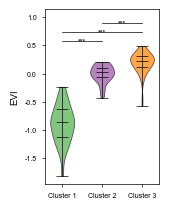

Overall Kruskal–Wallis (3 clusters): H=79.405, p=5.72e-18
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=39.326, p=3.59e-10
  Cluster 1 vs Cluster 3: H=60.251, p=8.35e-15
  Cluster 2 vs Cluster 3: H=23.653, p=1.15e-06
[Saved] Updated results for 'EVI' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


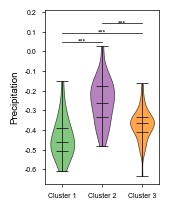

Overall Kruskal–Wallis (3 clusters): H=34.011, p=4.12e-08
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=23.534, p=1.23e-06
  Cluster 1 vs Cluster 3: H=11.987, p=0.000536
  Cluster 2 vs Cluster 3: H=19.135, p=1.22e-05
[Saved] Updated results for 'pr' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


In [19]:
species_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
# for env in PU.env_list:
for env in ['tas', 'rsds', 'EVI', 'pr']:
    PU.species_occ_env_violinplot(env, species_exclude)